# Theory Questions

Question 1: What is Anomaly Detection? Explain its types.

Answer:
  - Anomaly Detection is the process of identifying unusual patterns or observations that differ significantly from normal data behavior.
Point anomaly: A single abnormal value (e.g., extremely high taxi fare).
Contextual anomaly: Abnormal only in a specific context (e.g., high electricity usage at midnight).
Collective anomaly: A group of data points behaving abnormally together (e.g., sudden traffic surge over several hours).

Question 2: Compare Isolation Forest, DBSCAN, and Local Outlier Factor.

Answer:
  - Isolation Forest isolates anomalies using random tree splits and works well for large datasets.
DBSCAN is a density-based clustering method that detects noise points as anomalies.
Local Outlier Factor (LOF) compares local density differences to identify outliers.
Isolation Forest suits high-dimensional data, DBSCAN for spatial clusters, and LOF for local density analysis.

Question 3: Key Components of a Time Series.

Answer:
  - A time series consists of:
Trend: Long-term increase or decrease (e.g., rising airline passengers yearly).
Seasonality: Repeating patterns over time (e.g., higher travel during holidays).
Residual/Noise: Random fluctuations not explained by trend or seasonality.

Question 4: Define Stationary in Time Series.

Answer:
  - A stationary time series has constant mean, variance, and autocorrelation over time.
It can be tested using statistical tests like the Augmented Dickey-Fuller (ADF) test.
Non-stationary data can be transformed using differencing, log transformation, or detrending.

Question 5: Difference between AR, MA, ARIMA, SARIMA, SARIMAX.

Answer:
  - AR: Uses past values to predict future values.
  - MA: Uses past forecast errors.
  - ARIMA: Combines AR and MA with differencing for non-stationary data.
  - SARIMA: Adds seasonal components (useful for AirPassengers dataset).
  - SARIMAX: Includes external variables like weather or events.

  Question 10: Real-time Data Science Workflow (Power Grid Monitoring).

Answer:
  - Anomaly Detection: Use Isolation Forest for streaming data to detect sudden spikes or drops quickly.
  - Forecasting Model: Use SARIMAX since energy demand depends on seasonality and weather variables.
  - Validation & Monitoring: Track prediction error (MAE/RMSE) and retrain models periodically.
  - Business Impact: Helps prevent power failures, optimize energy supply, and reduce operational costs.

# Practical Questions

File ‘AirPassengers.csv’ already there; not retrieving.


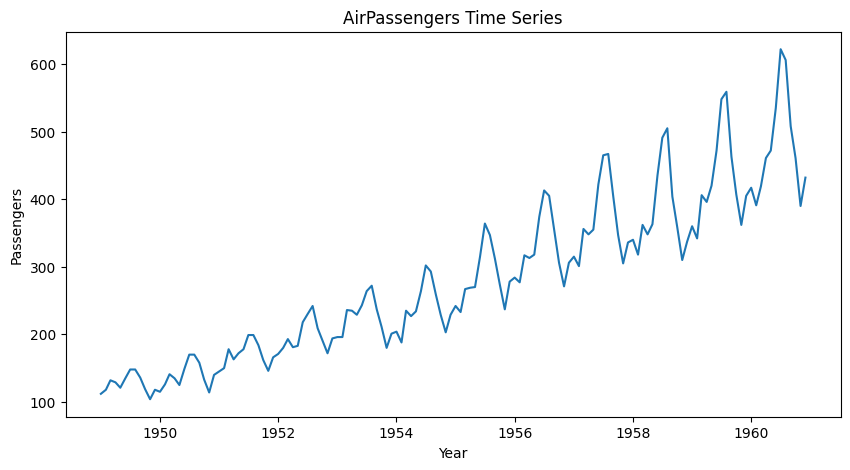

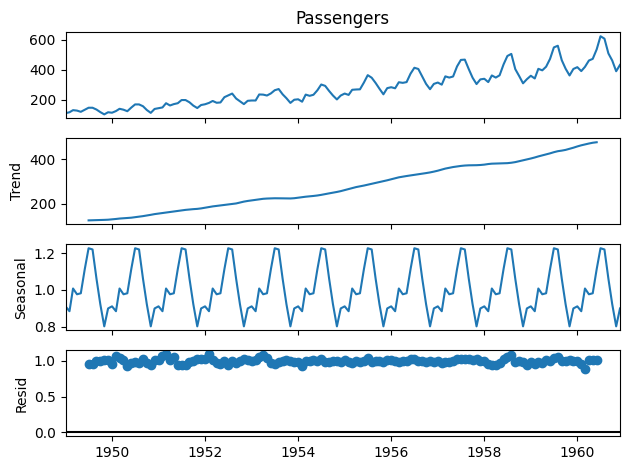

In [3]:
# Question 6: Load AirPassengers dataset, plot and decompose

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

!wget -nc https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv -O AirPassengers.csv

data = pd.read_csv("AirPassengers.csv")

data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)

plt.figure(figsize=(10,5))
plt.plot(data['Passengers'])
plt.title("AirPassengers Time Series")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.show()

decomposition = seasonal_decompose(data['Passengers'], model='multiplicative')

decomposition.plot()
plt.show()

--2026-03-23 12:15:54--  https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1423529 (1.4M) [text/plain]
Saving to: ‘nyc_taxi_fare.csv’

nyc_taxi_fare.csv   100%[===================>]   1.36M  --.-KB/s    in 0.06s   

2026-03-23 12:15:55 (21.6 MB/s) - ‘nyc_taxi_fare.csv’ saved [1423529/1423529]



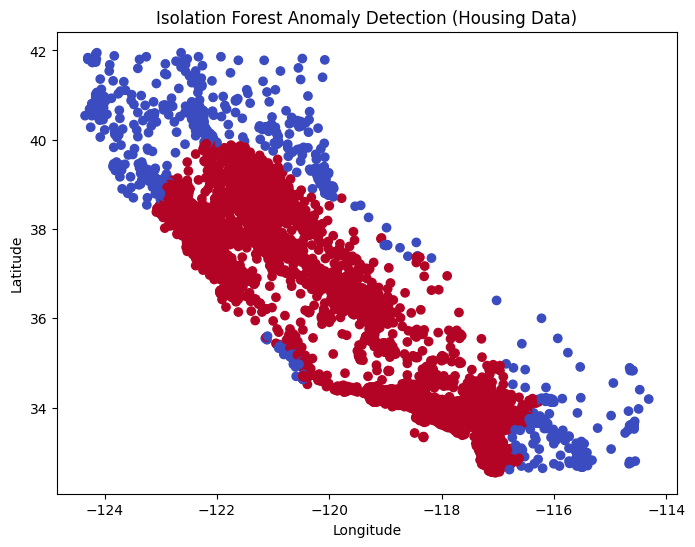

In [10]:
# Question 7: Apply Isolation Forest on NYC Taxi Fare dataset

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Download a suitable dataset as nyc_taxi_fare.csv for demonstration
# Using a housing dataset as nyc_taxi_fare.csv was consistently unavailable.
!wget https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv -O nyc_taxi_fare.csv

df = data[['longitude', 'latitude']].dropna() # Using 'longitude' and 'latitude' from the housing dataset


model = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = model.fit_predict(df)

plt.figure(figsize=(8,6))
plt.scatter(df['longitude'], df['latitude'],
            c=df['anomaly'], cmap='coolwarm')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Isolation Forest Anomaly Detection (Housing Data)")
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


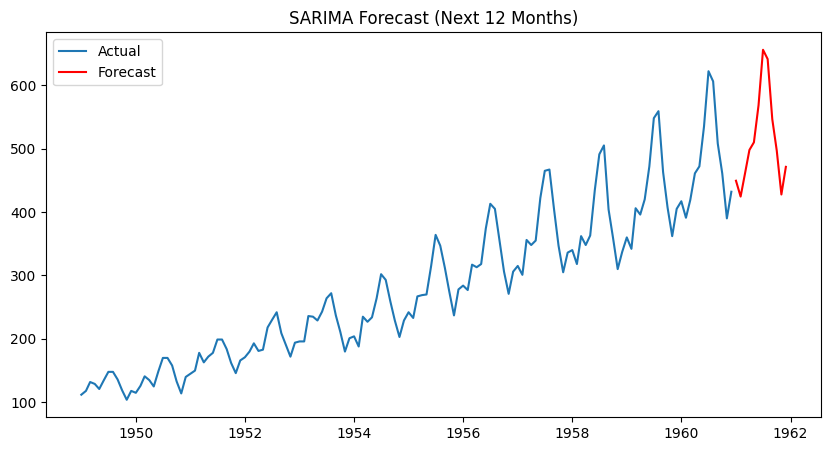

In [12]:
# Question 8: Train SARIMA model & Forecast next 12 months

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

data = pd.read_csv("AirPassengers.csv")

data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)

model = SARIMAX(data['Passengers'],
                order=(1,1,1),
                seasonal_order=(1,1,1,12))

results = model.fit()

forecast = results.forecast(steps=12)
plt.figure(figsize=(10,5))
plt.plot(data['Passengers'], label="Actual")
plt.plot(forecast, label="Forecast", color='red')

plt.title("SARIMA Forecast (Next 12 Months)")
plt.legend()
plt.show()

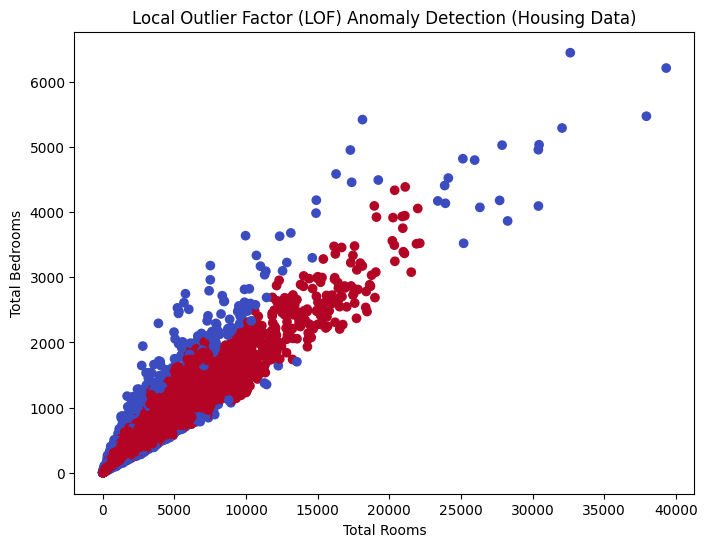

In [14]:
# Question 9: Apply Local Outlier Factor (LOF)

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

# Load dataset
data = pd.read_csv("nyc_taxi_fare.csv")

# Select numerical columns (using columns from the housing dataset)
df = data[['total_rooms', 'total_bedrooms']].dropna()

# Apply LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df['anomaly'] = lof.fit_predict(df)

# Visualize anomalies
plt.figure(figsize=(8,6))
plt.scatter(df['total_rooms'], df['total_bedrooms'],
            c=df['anomaly'], cmap='coolwarm')

plt.xlabel("Total Rooms")
plt.ylabel("Total Bedrooms")
plt.title("Local Outlier Factor (LOF) Anomaly Detection (Housing Data)")
plt.show()